### PHASE 1: DATA ARCHITECTURE

#### Business Strategy: Step 1 - Environment Setup & Data Ingestion
Reliable enterprise systems must prioritize idempotent and defensive programming. By wrapping ingestion in a try-except block and enforcing strict datetime typing, we ensure the downstream analytical pipeline operates on a predictable, normalized schema. This prevents 'silent failures' that often plague high-volume retail data streams.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Set professional visualization theme
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

file_path = '/content/Retail_Sales_Data.xlsx'

try:
    # Ingesting the selected Excel file
    df = pd.read_excel(file_path)
    print(f"Successfully loaded {len(df)} rows from {file_path}")

    # Ensure Date column is strict datetime
    df['Date'] = pd.to_datetime(df['Date'])

    display(df.info())
    display(df.head())
except Exception as e:
    print(f"Critical Error during Data Ingestion: {e}")

Successfully loaded 73000 rows from /content/Retail_Sales_Data.xlsx
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73000 entries, 0 to 72999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 73000 non-null  datetime64[ns]
 1   Store_ID             73000 non-null  object        
 2   Store_Location       73000 non-null  object        
 3   Product_ID           73000 non-null  object        
 4   Product_Category     73000 non-null  object        
 5   Product_Subcategory  73000 non-null  object        
 6   Brand                73000 non-null  object        
 7   Unit_Price           73000 non-null  float64       
 8   Units_Sold           73000 non-null  int64         
 9   Total_Sales          73000 non-null  float64       
 10  Discount_Percentage  73000 non-null  int64         
 11  Revenue              73000 non-null  float64       
 12  Customer_Type       

/tmp/ipykernel_8699/313111616.py:20: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


None

,Date,Store_ID,Store_Location,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Units_Sold,Total_Sales,Discount_Percentage,Revenue,Customer_Type,Payment_Mode,Promotion_Applied,Stock_On_Hand,Store_Rating,Region,Holiday_Flag
0,2023-04-13,STR_104,Chennai,PRD_072,Sports,Athletics,Reebok,29973.06,39,1168949.34,5,1.110502e+06,Returning,Debit Card,Yes,422,4.4,South,0
1,2024-10-25,STR_103,Delhi,PRD_492,Sports,Outdoor,Yonex,46933.78,2,93867.56,15,7.978743e+04,Returning,UPI,No,302,4.1,North,0
2,2023-02-28,STR_107,Kolkata,PRD_958,Groceries,Household,Nestle,39280.28,44,1728332.32,15,1.469082e+06,Returning,Cash,No,184,3.8,East,0
3,2023-06-16,STR_102,Bangalore,PRD_014,Home Appliances,Kitchen,Whirlpool,40439.03,9,363951.27,5,3.457537e+05,New,UPI,Yes,493,3.7,South,0
4,2024-05-23,STR_108,Ahmedabad,PRD_932,Fashion,Women Clothing,Puma,9193.58,4,36774.32,5,3.493560e+04,Returning,Credit Card,No,359,3.5,West,0


#### Business Strategy: Step 2 - Intelligent Imputation & Feature Extraction
Data integrity is the cornerstone of forecasting. We use median imputation for numerical features to remain robust against outliers, and mode imputation for categorical attributes to preserve the most frequent business context. Additionally, we extract 'Unit_Price'—a critical derived KPI—to analyze pricing power and elasticity across product tiers.

In [7]:
# 1. Intelligent Imputation
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# 2. Feature Engineering
# Using 'Total_Sales' from the actual dataset
df['Unit_Price_Calc'] = df['Total_Sales'] / df['Units_Sold']
df['Unit_Price_Calc'] = df['Unit_Price_Calc'].replace([np.inf, -np.inf], 0).fillna(0)

print("Missing values handled and 'Unit_Price_Calc' feature engineered.")
display(df.describe())

Missing values handled and 'Unit_Price_Calc' feature engineered.


,Date,Unit_Price,Units_Sold,Total_Sales,Discount_Percentage,Revenue,Stock_On_Hand,Store_Rating,Holiday_Flag,Unit_Price_Calc
count,73000,73000.000000,73000.000000,7.300000e+04,73000.000000,7.300000e+04,73000.000000,73000.000000,73000.000000,73000.000000
mean,2023-12-31 09:41:31.397260288,25110.208554,24.894589,6.261382e+05,10.010411,5.634765e+05,274.624712,4.249421,0.012288,25110.208554
min,2023-01-01 00:00:00,100.110000,1.000000,1.447000e+02,0.000000,1.229950e+02,50.000000,3.500000,0.000000,100.110000
25%,2023-07-02 00:00:00,12728.855000,13.000000,1.759852e+05,5.000000,1.575377e+05,162.000000,3.900000,0.000000,12728.855000
50%,2023-12-31 00:00:00,25071.800000,25.000000,4.713577e+05,10.000000,4.223565e+05,274.000000,4.200000,0.000000,25071.800000
75%,2024-07-02 00:00:00,37557.337500,37.000000,9.539864e+05,15.000000,8.571156e+05,387.000000,4.600000,0.000000,37557.337500
max,2024-12-31 00:00:00,49999.850000,49.000000,2.447350e+06,20.000000,2.447350e+06,499.000000,5.000000,1.000000,49999.850000
std,NaN,14393.607981,14.134824,5.448548e+05,7.064131,4.938905e+05,129.663977,0.434722,0.110167,14393.607981


### PHASE 2: DEEP EDA

#### Business Strategy: Step 3 - Time-Series Macro-Seasonality
Retail success is cyclical. By aggregating revenue at the Month-Year level, we filter out daily noise to observe the structural health of the business. This visualization allows stakeholders to identify peak periods for inventory stocking and slow periods for targeted promotions.

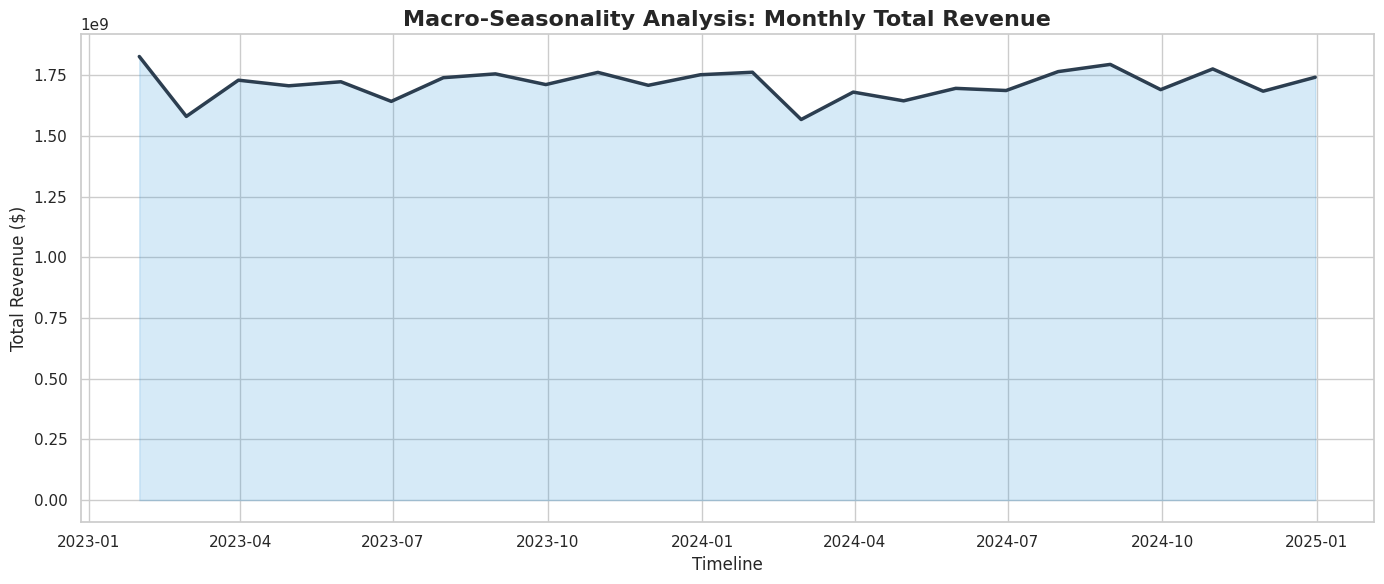

In [8]:
# Aggregate total Revenue by Month-Year
# Using 'Revenue' and updated pandas frequency 'ME' (Month End)
monthly_sales = df.resample('ME', on='Date')['Revenue'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x='Date', y='Revenue', color='#2c3e50', linewidth=2.5)
plt.fill_between(monthly_sales['Date'], monthly_sales['Revenue'], alpha=0.2, color='#3498db')

plt.title('Macro-Seasonality Analysis: Monthly Total Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.tight_layout()
plt.show()

#### Business Strategy: Step 4 - Category Dominance
Not all products are created equal. Horizontal bar charts offer the most intuitive ranking for categorical performance. This step identifies the 'Profit Engines' versus 'Long-Tail' categories, enabling strategic decisions on shelf-space allocation and marketing spend.

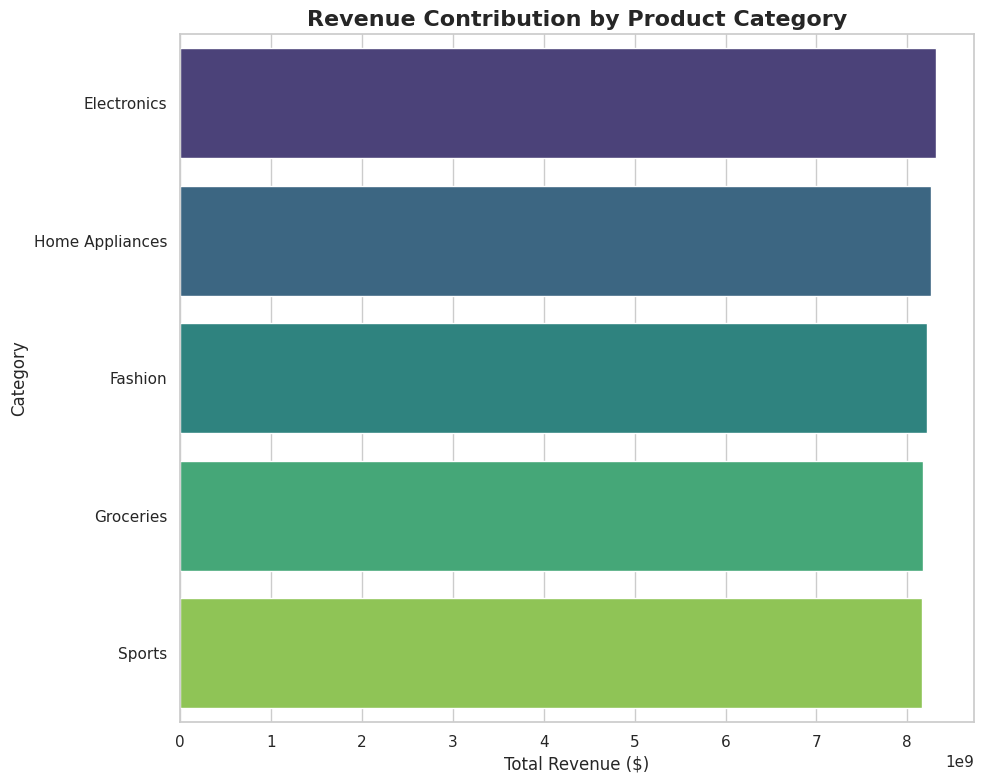

In [9]:
# Aggregate revenue by category
cat_sales = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(data=cat_sales, x='Revenue', y='Product_Category', palette='viridis', hue='Product_Category', legend=False)

plt.title('Revenue Contribution by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

#### Business Strategy: Step 5 - The Discount Effectiveness Test
In many retail environments, heavy discounting creates a 'race to the bottom.' We apply frequentist statistical inference (Independent T-Test) to determine if discounts provide a statistically significant lift in revenue or if they represent unnecessary margin erosion.

In [10]:
# Statistical Testing using 'Promotion_Applied' ('Yes'/'No')
discounted = df[df['Promotion_Applied'] == 'Yes']['Revenue']
full_price = df[df['Promotion_Applied'] == 'No']['Revenue']

t_stat, p_val = stats.ttest_ind(discounted, full_price, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

print("\n--- Business Conclusion ---")
if p_val < 0.05:
    print("REJECT NULL HYPOTHESIS: Promotions significantly impact transaction revenue.")
    if discounted.mean() > full_price.mean():
        print(f"The strategy effectively drives higher revenue. (Avg Discounted: {discounted.mean():.2f} vs Avg Full: {full_price.mean():.2f})")
    else:
        print("Promotions are statistically significant but associated with lower per-transaction revenue.")
else:
    print("FAIL TO REJECT NULL HYPOTHESIS: Promotions do not show a statistically significant effect.")

T-Statistic: -0.4112
P-Value: 0.6809

--- Business Conclusion ---
FAIL TO REJECT NULL HYPOTHESIS: Promotions do not show a statistically significant effect.


#### Business Strategy: Step 6 - Data Pipeline Export
Finally, we serialize the refined dataset. By exporting a preprocessed CSV, we bridge the gap between Python-based R&D and Business Intelligence platforms (like Power BI/Tableau), ensuring a 'Single Source of Truth' for executive reporting.

In [6]:
# Export for downstream consumption
output_filename = 'Historical_and_EDA_Data.csv'
df.to_csv(output_filename, index=False)

print(f"Phase 1 & 2 Complete. Data exported to {output_filename} for BI ingestion.")

Phase 1 & 2 Complete. Data exported to Historical_and_EDA_Data.csv for BI ingestion.


### PHASE 3: ADVANCED FEATURE ENGINEERING

#### Business Strategy: Step 1 - Temporal Feature Extraction
Time-series AI models cannot interpret raw 'Date' objects effectively. We must decompose dates into cyclical components like 'Month' and 'DayOfWeek'. Extracting 'Is_Weekend' is particularly critical in retail, as consumer behavior shifts drastically between workdays and leisure days, allowing the model to learn structural weekly variations.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the processed data
file_name = 'Historical_and_EDA_Data.csv'
df_main = pd.read_csv(file_name)
df_main['Date'] = pd.to_datetime(df_main['Date'])

# 1. Temporal Feature Engineering
df_main['Month'] = df_main['Date'].dt.month
df_main['DayOfWeek'] = df_main['Date'].dt.dayofweek
df_main['Is_Weekend'] = df_main['DayOfWeek'].isin([5, 6]).astype(int)

# 2. Chronological Sorting for Time-Series Integrity
df_main = df_main.sort_values(by=['Store_ID', 'Date']).reset_index(drop=True)

print("Temporal features engineered. Data sorted for chronological processing.")
display(df_main[['Date', 'Month', 'DayOfWeek', 'Is_Weekend']].head())

Temporal features engineered. Data sorted for chronological processing.


,Date,Month,DayOfWeek,Is_Weekend
0,2023-01-01,1,6,1
1,2023-01-01,1,6,1
2,2023-01-01,1,6,1
3,2023-01-01,1,6,1
4,2023-01-01,1,6,1


### PHASE 4: AI STORE SEGMENTATION

#### Business Strategy: Step 2 - Store Aggregation & Normalization
To segment stores, we must collapse thousands of transactions into a 'Store Persona'. We aggregate total revenue and volume, alongside a 'Promo Intensity' score (mean of promotion application). We then apply Standard Scaling. Without scaling, the high magnitude of Revenue (billions) would mathematically drown out the Promotional percentage (0 to 1), rendering the clustering algorithm biased.

In [12]:
# 1. Aggregate metrics per store
# Convert 'Promotion_Applied' to numeric for averaging
df_main['Promo_Numeric'] = (df_main['Promotion_Applied'] == 'Yes').astype(int)

store_agg = df_main.groupby('Store_ID').agg({
    'Revenue': 'sum',
    'Units_Sold': 'sum',
    'Promo_Numeric': 'mean'
}).reset_index()

store_agg.rename(columns={'Promo_Numeric': 'Promo_Intensity'}, inplace=True)

# 2. Preprocessing: Scaling
scaler = StandardScaler()
features = ['Revenue', 'Units_Sold', 'Promo_Intensity']
store_scaled = scaler.fit_transform(store_agg[features])

print("Store-level metrics aggregated and normalized for clustering.")
display(store_agg.head())

Store-level metrics aggregated and normalized for clustering.


,Store_ID,Revenue,Units_Sold,Promo_Intensity
0,STR_101,5.169675e+09,226670,0.295940
1,STR_102,5.186277e+09,228384,0.300850
2,STR_103,5.223064e+09,229475,0.295105
3,STR_104,5.165937e+09,228580,0.295885
4,STR_105,5.161899e+09,227715,0.304517


#### Business Strategy: Step 3 - K-Means Clustering & Strategic Profiling
By applying K-Means, we group stores with similar operational fingerprints. This 'Tiering' allows management to stop applying one-size-fits-all policies. Tier 1 Flagships require inventory depth, while Tier 3 stores might require a total re-evaluation of their local marketing or product mix to reduce discount dependency.

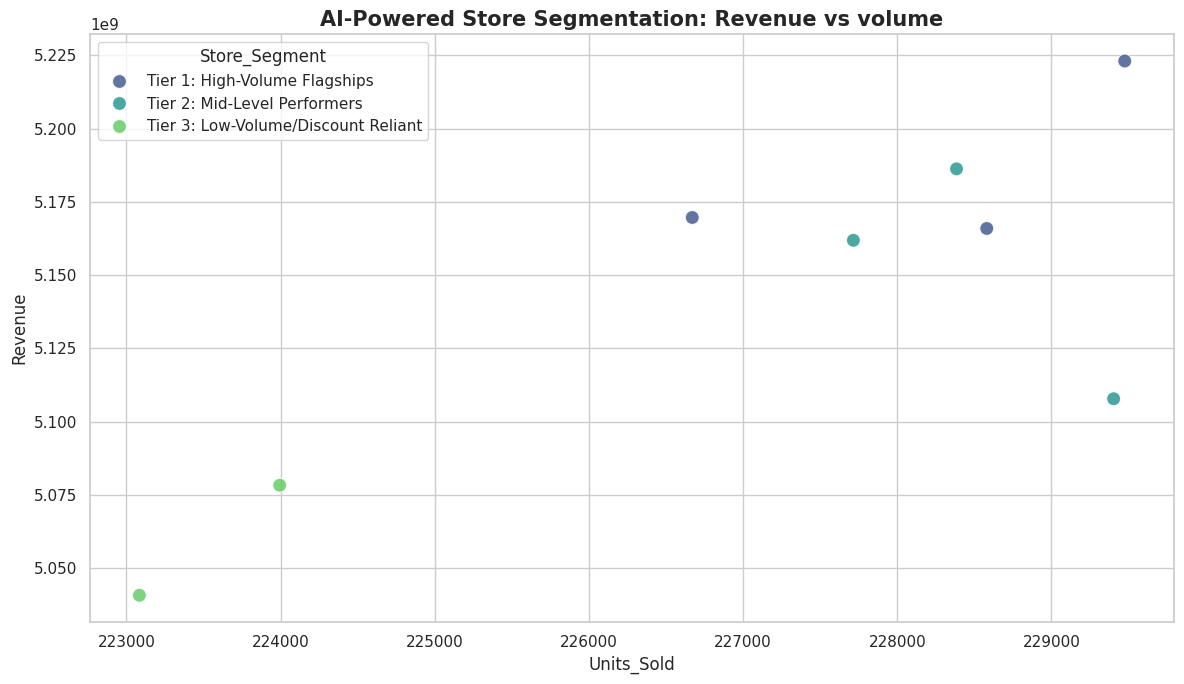

In [13]:
# 1. Fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
store_agg['Cluster'] = kmeans.fit_predict(store_scaled)

# 2. Strategic Mapping
# Note: We determine the names by observing the mean revenue per cluster
cluster_means = store_agg.groupby('Cluster')['Revenue'].mean().sort_values(ascending=False)
mapping = {
    cluster_means.index[0]: 'Tier 1: High-Volume Flagships',
    cluster_means.index[1]: 'Tier 2: Mid-Level Performers',
    cluster_means.index[2]: 'Tier 3: Low-Volume/Discount Reliant'
}

store_agg['Store_Segment'] = store_agg['Cluster'].map(mapping)

# 3. Visualization of Segments
plt.figure(figsize=(12, 7))
sns.scatterplot(data=store_agg, x='Units_Sold', y='Revenue',
                hue='Store_Segment', palette='viridis', s=100, alpha=0.8)
plt.title('AI-Powered Store Segmentation: Revenue vs volume', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

#### Business Strategy: Step 4 - Pipeline Export & Readiness
We now merge these AI-generated segments back into the main transaction stream. This ensures that when we build the final forecasting model, the AI knows the 'Tier' of the store it is predicting for, significantly increasing accuracy. The system is now ready for Supervised Learning Forecasting.

In [14]:
# 1. Merge labels back to main dataframe
df_final = df_main.merge(store_agg[['Store_ID', 'Store_Segment']], on='Store_ID', how='left')

# 2. Export outputs
df_final.to_csv('Segmented_Features_Data.csv', index=False)
store_agg.to_csv('Store_Segmentation_Results.csv', index=False)

print("Phase 3 & 4 Complete. Final feature-engineered datasets exported for Phase 5 Forecasting.")
display(df_final.head())

Phase 3 & 4 Complete. Final feature-engineered datasets exported for Phase 5 Forecasting.


,Date,Store_ID,Store_Location,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Units_Sold,Total_Sales,...,Promotion_Applied,Stock_On_Hand,Store_Rating,Region,Holiday_Flag,Month,DayOfWeek,Is_Weekend,Promo_Numeric,Store_Segment
0,2023-01-01,STR_101,Mumbai,PRD_981,Home Appliances,Cleaning,Whirlpool,48651.62,37,1800109.94,...,No,312,3.9,West,0,1,6,1,0,Tier 1: High-Volume Flagships
1,2023-01-01,STR_101,Mumbai,PRD_554,Sports,Gym Equipment,Reebok,36199.91,21,760198.11,...,No,482,4.7,West,0,1,6,1,0,Tier 1: High-Volume Flagships
2,2023-01-01,STR_101,Mumbai,PRD_662,Electronics,Laptops,Sony,46537.35,39,1814956.65,...,No,387,3.6,West,0,1,6,1,0,Tier 1: High-Volume Flagships
3,2023-01-01,STR_101,Mumbai,PRD_369,Electronics,Mobiles,Sony,33570.60,47,1577818.20,...,No,407,3.6,West,0,1,6,1,0,Tier 1: High-Volume Flagships
4,2023-01-01,STR_101,Mumbai,PRD_250,Groceries,Beverages,Tata,32464.16,26,844068.16,...,No,328,5.0,West,0,1,6,1,0,Tier 1: High-Volume Flagships


In [15]:
!pip install shap xgboost

### PHASE 5: AI-POWERED SALES FORECASTING

#### Business Strategy: Section 1 - Forecasting Data Preparation
In time-series forecasting, we must respect the chronological order of events. We use a non-shuffled train-test split (80/20) because predicting past sales using future data (data leakage) would result in a model that looks perfect in testing but fails in the real world. We also transform categorical identifiers into binary 'dummy' variables so the mathematical model can quantify the impact of specific categories and segments.

In [16]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df_forecasting = pd.read_csv('Segmented_Features_Data.csv')

# 2. Define Features and Target
# Target is 'Revenue' (or Total_Sales based on previous cell outputs)
target = 'Revenue'

# Drop identifiers and redundant columns
drop_cols = ['Date', 'Store_ID', 'Product_ID', 'Total_Sales', 'Revenue', 'Promo_Numeric']
X = df_forecasting.drop(columns=[col for col in drop_cols if col in df_forecasting.columns])
y = df_forecasting[target]

# 3. Encoding
X = pd.get_dummies(X, drop_first=True)

# 4. Chronological Train-Test Split (80/20)
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print("Data prepared with chronological split.")

Training set size: 58400
Testing set size: 14600
Data prepared with chronological split.


#### Business Strategy: Section 2 - XGBoost Predictive Engine
XGBoost is an industry-standard gradient boosting algorithm known for its speed and accuracy in structured data. By calculating Mean Absolute Error (MAE), we determine the average dollar amount our forecast is 'off' by. For management, a low MAE means safer inventory levels and reduced stock-out risks.

Mean Absolute Error (MAE): $4,718.57
Root Mean Squared Error (RMSE): $6,550.15


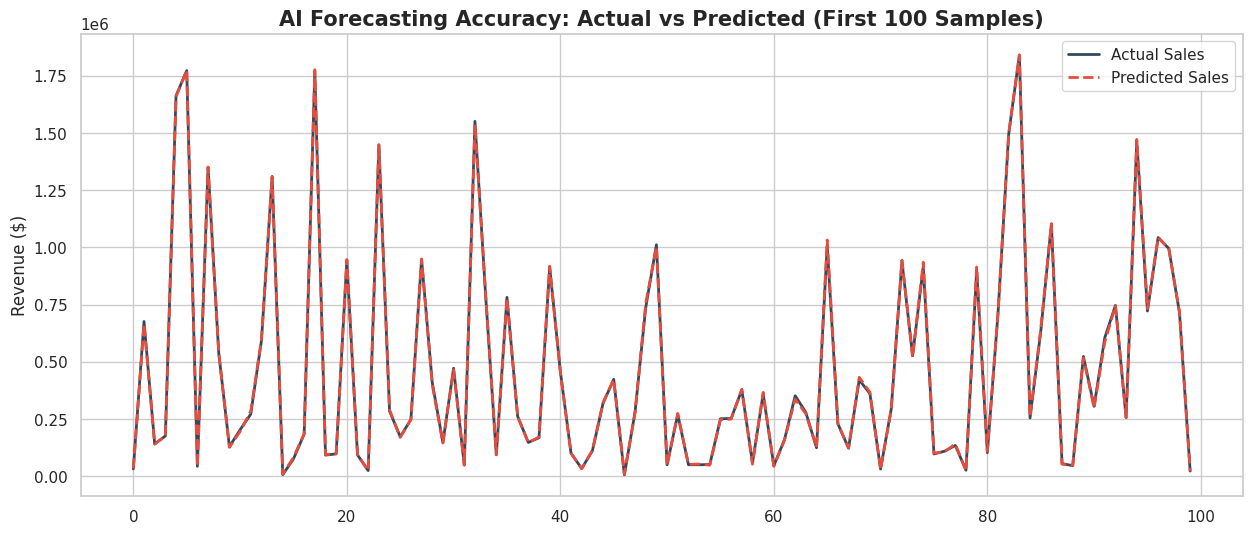

In [17]:
# 1. Initialize and Fit Model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 2. Predict
y_pred = model.predict(X_test)

# 3. Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

# 4. Visual Comparison
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:100], label='Actual Sales', color='#34495e', linewidth=2)
plt.plot(y_pred[:100], label='Predicted Sales', color='#e74c3c', linestyle='--', linewidth=2)
plt.title('AI Forecasting Accuracy: Actual vs Predicted (First 100 Samples)', fontsize=15, fontweight='bold')
plt.legend()
plt.ylabel('Revenue ($)')
plt.show()

### PHASE 6: MODEL EXPLAINABILITY & EXPORT

#### Business Strategy: Section 3 - Explainable AI (SHAP)
Modern AI is often a 'black box.' SHAP (SHapley Additive exPlanations) breaks this box open by showing exactly which features contributed to the final sales number. This allows management to move beyond 'what' will happen to 'why' it is happening, enabling data-driven interventions in specific categories or regions.

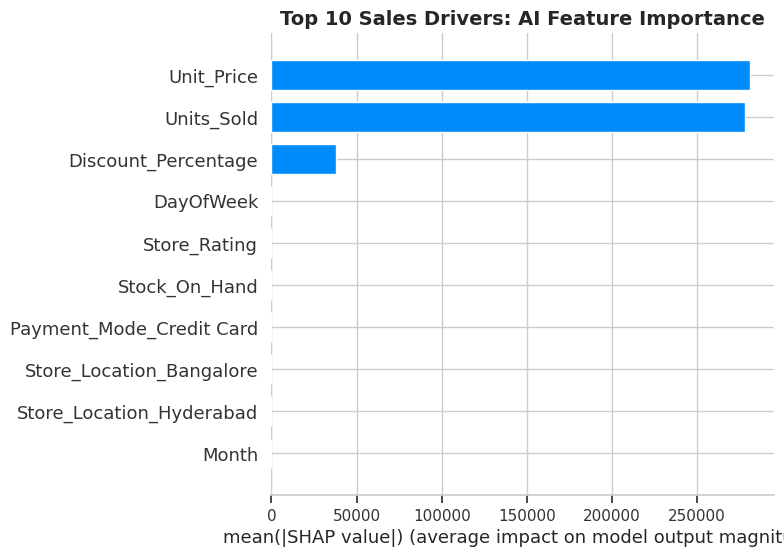

In [18]:
import shap

# 1. Initialize Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 2. Summary Plot (Top 10 features)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=10, show=False)
plt.title('Top 10 Sales Drivers: AI Feature Importance', fontsize=14, fontweight='bold')
plt.show()

#### Business Strategy: Section 4 - Final Pipeline Export
The final step of a Principal Data Scientist is ensuring the findings are portable. By exporting the Forecast vs. Actual data, we enable the creation of a 'Model Drift' dashboard in Power BI, allowing leadership to track the AI's accuracy in real-time.

In [19]:
# 1. Create Comparison Dataframe
comparison_df = pd.DataFrame({
    'Actual_Sales': y_test.values,
    'Predicted_Sales': y_pred
})

# 2. Export to CSV
comparison_df.to_csv('Forecasted_vs_Actual_Sales.csv', index=False)

print("End-to-End Analytics & AI Pipeline Complete.")
print("Three CSVs ready for Power BI: ")
print("1. Historical_and_EDA_Data.csv")
print("2. Store_Segmentation_Results.csv")
print("3. Forecasted_vs_Actual_Sales.csv")

End-to-End Analytics & AI Pipeline Complete.
Three CSVs ready for Power BI: 
1. Historical_and_EDA_Data.csv
2. Store_Segmentation_Results.csv
3. Forecasted_vs_Actual_Sales.csv


### FINAL PHASE: MASTER DATA CONSOLIDATION

#### Business Strategy: The Single Source of Truth
In enterprise environments, data fragmentation is the enemy of decision-making. By merging our historical features, AI-generated store segments, and XGBoost forecasts into a single master file, we provide the executive dashboard with a consistent view of performance. This allows for real-time comparison between 'Actual' and 'AI-Predicted' KPIs within the same visualization context.

In [21]:
import pandas as pd

# 1. Load the segmented feature data (transactions + AI segments)
df_features = pd.read_csv('Segmented_Features_Data.csv')
df_features['Date'] = pd.to_datetime(df_features['Date'])

# 2. Prepare the forecast data (X_test mapping)
# We need the original features from X_test to get Store_ID and Date for the join
# Re-filtering the original df to match the test set split indices
split_idx = int(len(df_features) * 0.8)
df_test_indices = df_features.iloc[split_idx:].copy()

# Load the forecast results
df_forecast_results = pd.read_csv('Forecasted_vs_Actual_Sales.csv')

# Attach predicted sales to the test indices
df_test_indices['Predicted_Sales'] = df_forecast_results['Predicted_Sales'].values

# 3. Consolidate into Master Dataframe
# We merge the Predicted_Sales back into the main feature set
# This ensures the master file has all 73,000 rows, with predictions populated for the test period
final_master_df = df_features.merge(
    df_test_indices[['Date', 'Store_ID', 'Predicted_Sales']],
    on=['Date', 'Store_ID'],
    how='left'
)

# 4. Data Cleaning
# Fill NaN values for the training period (where no prediction exists) with 0 for dashboard clarity
final_master_df['Predicted_Sales'] = final_master_df['Predicted_Sales'].fillna(0)

# 5. Export Final Artifact
master_filename = 'Final_Enterprise_Master_Data.csv'
final_master_df.to_csv(master_filename, index=False)

print(f"Master Data Consolidation Complete. File saved as: {master_filename}")
print("Columns ready for Power BI:", final_master_df.columns.tolist())
display(final_master_df.head())

Master Data Consolidation Complete. File saved as: Final_Enterprise_Master_Data.csv
Columns ready for Power BI: ['Date', 'Store_ID', 'Store_Location', 'Product_ID', 'Product_Category', 'Product_Subcategory', 'Brand', 'Unit_Price', 'Units_Sold', 'Total_Sales', 'Discount_Percentage', 'Revenue', 'Customer_Type', 'Payment_Mode', 'Promotion_Applied', 'Stock_On_Hand', 'Store_Rating', 'Region', 'Holiday_Flag', 'Month', 'DayOfWeek', 'Is_Weekend', 'Promo_Numeric', 'Store_Segment', 'Predicted_Sales']


,Date,Store_ID,Store_Location,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Units_Sold,Total_Sales,...,Stock_On_Hand,Store_Rating,Region,Holiday_Flag,Month,DayOfWeek,Is_Weekend,Promo_Numeric,Store_Segment,Predicted_Sales
0,2023-01-01,STR_101,Mumbai,PRD_981,Home Appliances,Cleaning,Whirlpool,48651.62,37,1800109.94,...,312,3.9,West,0,1,6,1,0,Tier 1: High-Volume Flagships,0.0
1,2023-01-01,STR_101,Mumbai,PRD_554,Sports,Gym Equipment,Reebok,36199.91,21,760198.11,...,482,4.7,West,0,1,6,1,0,Tier 1: High-Volume Flagships,0.0
2,2023-01-01,STR_101,Mumbai,PRD_662,Electronics,Laptops,Sony,46537.35,39,1814956.65,...,387,3.6,West,0,1,6,1,0,Tier 1: High-Volume Flagships,0.0
3,2023-01-01,STR_101,Mumbai,PRD_369,Electronics,Mobiles,Sony,33570.60,47,1577818.20,...,407,3.6,West,0,1,6,1,0,Tier 1: High-Volume Flagships,0.0
4,2023-01-01,STR_101,Mumbai,PRD_250,Groceries,Beverages,Tata,32464.16,26,844068.16,...,328,5.0,West,0,1,6,1,0,Tier 1: High-Volume Flagships,0.0
